In [35]:
import pandas as pd
import re
import seaborn as sns
import matplotlib.pyplot as plt
import math

In [36]:
df = pd.read_excel("wyniki.xlsx")
df = df.replace(',', '.', regex=True)
df = df.loc[:, ~df.columns.str.endswith(".1")]

In [37]:
df.columns = [
    "ankieta", "Płeć", "Matematyka rozszerzona", "Etap edukacji",
    "statystyka_studia", "testy_diag", "artykuly_naukowe",
    "srednia_kolano", "srednia_sklon", "mediana_rehab",
    "mediana_sport", "dominanta_wizyty", "rozstep_biodro",
    "q1", "odchylenie", "wsp_zmiennosci",
    "Odpowiedź do zadania 8", "Odpowiedź do zadania 9",
    "Odpowiedź do zadania 10", "Rok studiów", "wynik"
]


In [38]:
df

,ankieta,Płeć,Matematyka rozszerzona,Etap edukacji,statystyka_studia,testy_diag,artykuly_naukowe,srednia_kolano,srednia_sklon,mediana_rehab,...,dominanta_wizyty,rozstep_biodro,q1,odchylenie,wsp_zmiennosci,Odpowiedź do zadania 8,Odpowiedź do zadania 9,Odpowiedź do zadania 10,Rok studiów,wynik
0,1.0,K,Nie,Tak. studia,Tak,Tak. tak,Tak. tak,X,X,C. 8,...,B. 3,X,A. 25% wyników,B. Wyniki są skupione blisko średniej,X,X,X,X,X,4
1,2.0,K,Nie,Nie,Tak,Tak. tak,Tak. tak,B. 130,C. 8.39,C. 8,...,B. 3,C. 40,B. 50% wyników,B. Wyniki są skupione blisko średniej,A. Porównujemy sednie w tej samej jednostce/gr...,D. Test ma wysoką dokładność ogólną,B. Test rzadko daje wyniki fałszywie dodatnie,A,X,7
2,3.0,K,Nie,Tak. studia,Tak,Tak. tak,Tak. nie,B. 130,C. 8.39,C. 8,...,B. 3,C. 40,A. 25% wyników,B. Wyniki są skupione blisko średniej,X,A. Test rzadko daje wyniki fałszywie dodatnie,C. Test rzadko daje wyniki fałszywie ujemne,X,X,7
3,4.0,K,Nie,Tak. szkoła ponadpodstawowa,Tak,Tak. tak,Tak. nie,B. 130,C. 8.39,C. 8,...,B. 3,C. 40,A. 25% wyników,B. Wyniki są skupione blisko średniej,C. Chcemy porównać zmienność cech mierzonych w...,C. Test rzadko pomija pacjentów z niestabilnością,B. Test rzadko daje wyniki fałszywie dodatnie,X,X,10
4,5.0,K,Tak,Tak. studia,Tak,Tak. nie,Tak. nie,B. 130,C. 8.39,C. 8,...,B. 3,C. 40,A. 25% wyników,B. Wyniki są skupione blisko średniej,X,D. Test ma wysoką dokładność ogólną,X,X,X,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,NaN,K,Tak,Tak. studia,Tak,Tak. nie,Nie,B. 130,X,C. 8,...,D. 5,X,X,B. Wyniki są skupione blisko średniej,C. Chcemy porównać zmienność cech mierzonych w...,X,X,X,Nie,5
246,NaN,K,Nie,Tak. studia,Tak,Tak. tak,Tak. tak,B. 130,X,C. 8,...,B. 3,X,X,B. Wyniki są skupione blisko średniej,C. Chcemy porównać zmienność cech mierzonych w...,X,X,X,Nie,6
247,NaN,K,Tak,Tak. szkoła policealna,Nie,Nie,Tak. tak,B. 130,C. 8.39,C. 8,...,B. 3,B. 30,A. 25% wyników,B. Wyniki są skupione blisko średniej,A. Porównujemy sednie w tej samej jednostce/gr...,A. Test rzadko daje wyniki fałszywie dodatnie,C. Test rzadko daje wyniki fałszywie ujemne,X,Nie,6
248,NaN,M,Nie,Tak. studia,Tak,Tak. tak,Tak. tak,B. 130,C. 8.39,C. 8,...,B. 3,C. 40,C. 75% wyników,A. Wyniki są bardzo zróżnicowane,A. Porównujemy sednie w tej samej jednostce/gr...,A. Test rzadko daje wyniki fałszywie dodatnie,A. Test często wykrywa chorobę u osób zdrowych,A,Nie,7


In [39]:
df["Płeć"] = df["Płeć"].map({
    "M": "Mężczyzna",
    "K": "Kobieta"
})

In [40]:
def extract_number(x):
    if isinstance(x, str):
        match = re.search(r"[-+]?\d*\.?\d+", x)
        return float(match.group()) if match else None
    return x

cols_num = [
    "srednia_kolano", "srednia_sklon", "mediana_rehab",
    "mediana_sport", "dominanta_wizyty", "rozstep_biodro"
]

for col in cols_num:
    df[col] = df[col].apply(extract_number)

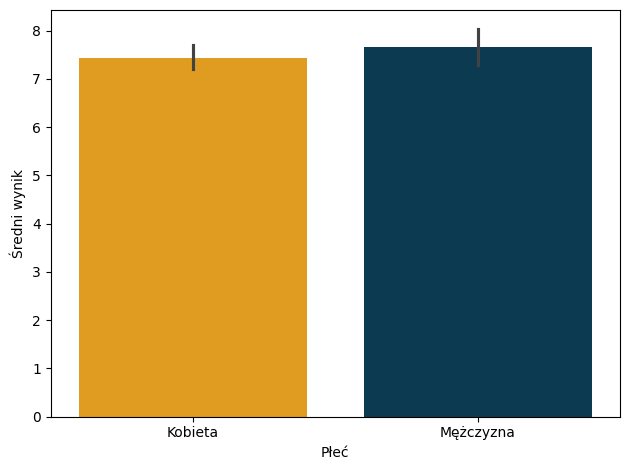

In [41]:
sns.barplot(data=df, x="Płeć", y="wynik", errorbar=('ci'), hue='Płeć', palette=["#ffa600", "#003f5c"])

plt.xlabel("Płeć")
plt.ylabel("Średni wynik")

plt.tight_layout()
plt.savefig("test/sredni_wynik_plec.svg", dpi=300)

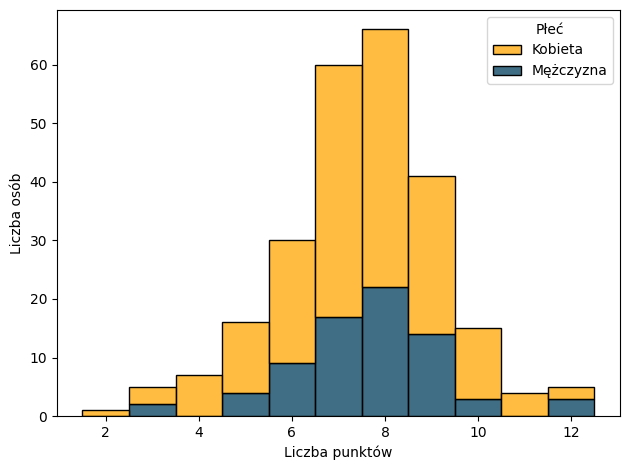

In [42]:
ax = sns.histplot(data=df, x="wynik", discrete=True, hue='Płeć', palette=["#ffa600", "#003f5c"], multiple="stack")

plt.xlabel("Liczba punktów")
plt.ylabel("Liczba osób")

plt.tight_layout()
plt.savefig("test/wynik_plec.svg", dpi=300)

In [43]:
srednie = df.groupby("Płeć")["wynik"].mean()
print(srednie)

Płeć
Kobieta      7.437500
Mężczyzna    7.662162
Name: wynik, dtype: float64


In [44]:
counts = df.groupby(["Płeć", "wynik"]).size()
print(counts)

Płeć       wynik
Kobieta    2         1
           3         3
           4         7
           5        12
           6        21
           7        43
           8        44
           9        27
           10       12
           11        4
           12        2
Mężczyzna  3         2
           5         4
           6         9
           7        17
           8        22
           9        14
           10        3
           12        3
dtype: int64


In [45]:
df["Płeć"].value_counts()

Płeć
Kobieta      176
Mężczyzna     74
Name: count, dtype: int64

In [46]:
df["Rok studiów"] = df["Rok studiów"].map({
    "Nie": "I rok",
    "X": "V rok",
})

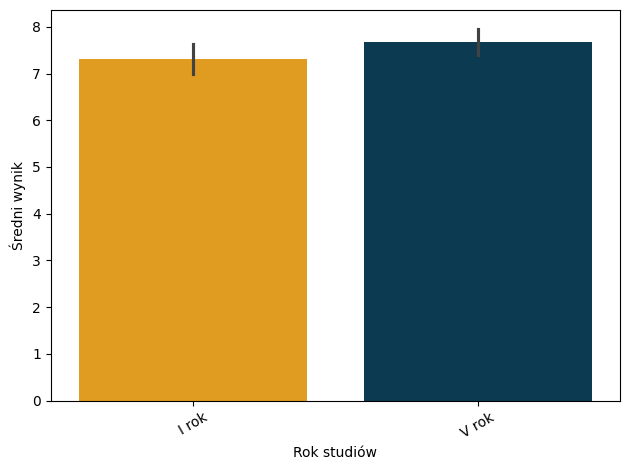

In [47]:
order = ["I rok", "V rok"]

sns.barplot(data=df, x="Rok studiów", y="wynik", hue="Rok studiów", hue_order=order, palette=["#ffa600", "#003f5c"], order=order)
plt.xticks(rotation=30)

plt.xlabel("Rok studiów")
plt.ylabel("Średni wynik")

plt.tight_layout()
plt.savefig("test/sredni_wynik_rok.svg", dpi=300)

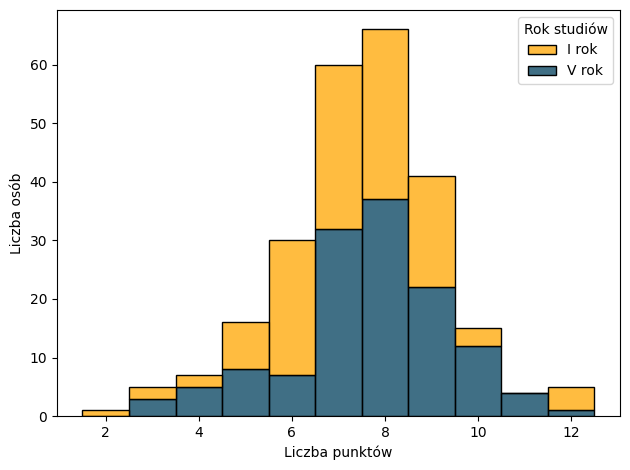

In [48]:
order = ["I rok", "V rok"]

ax = sns.histplot(data=df, x="wynik", discrete=True, hue='Rok studiów', palette=["#ffa600", "#003f5c"], hue_order=order, multiple="stack")

plt.xlabel("Liczba punktów")
plt.ylabel("Liczba osób")

plt.tight_layout()
plt.savefig("test/wynik_rok.svg", dpi=300)

In [49]:
srednie = df.groupby("Rok studiów")["wynik"].mean()
srednie

Rok studiów
I rok    7.319328
V rok    7.671756
Name: wynik, dtype: float64

In [50]:
counts = df.groupby(["Rok studiów", "wynik"]).size()
print(counts)

Rok studiów  wynik
I rok        2         1
             3         2
             4         2
             5         8
             6        23
             7        28
             8        29
             9        19
             10        3
             12        4
V rok        3         3
             4         5
             5         8
             6         7
             7        32
             8        37
             9        22
             10       12
             11        4
             12        1
dtype: int64


In [51]:
df["Rok studiów"].value_counts()

Rok studiów
V rok    131
I rok    119
Name: count, dtype: int64

In [52]:
df["Etap edukacji"].unique()

array([' Tak. studia', 'Nie', 'Tak. studia',
       'Tak. szkoła ponadpodstawowa', 'X', 'Tak. szkoła podstawowa',
       'Tak. szkoła policealna'], dtype=object)

In [53]:
df["Etap edukacji"] = df["Etap edukacji"].map({
    "Nie": "Nigdy",
    "Tak. szkoła ponadpodstawowa": "Szkoła ponadpodstawowa",
    " Tak. studia": "Studia",
    "Tak. studia": "Studia",
    "Tak. szkoła podstawowa": "Szkoła podstawowa",
    "Tak. szkoła policealna": "Szkoła policealna",
    "X": "Nigdy"
})

C:\Users\Admin\AppData\Local\Temp\ipykernel_24288\290272631.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


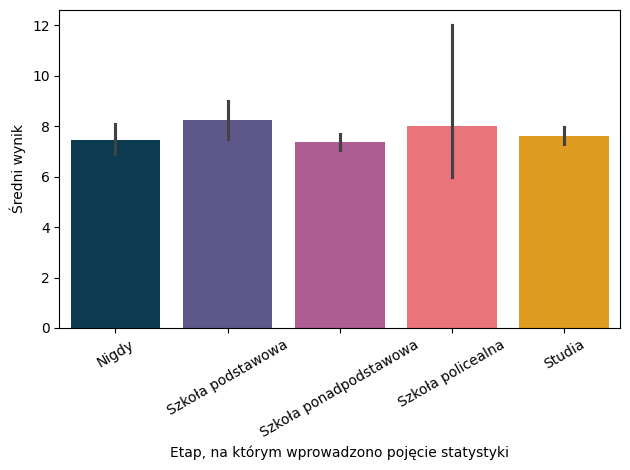

In [54]:
order = ["Nigdy", "Szkoła podstawowa", "Szkoła ponadpodstawowa", "Szkoła policealna", "Studia"]

sns.barplot(data=df, x="Etap edukacji", y="wynik", errorbar=('ci'), hue='Etap edukacji', palette=["#003f5c", "#575092", "#bb4e99", "#ff5f68", "#ffa600"], hue_order=order, order=order)
plt.legend().remove() 
plt.ylabel("Średni wynik")
plt.xlabel("Etap, na którym wprowadzono pojęcie statystyki")
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig("test/sredni_wynik_statystyka_edukacja.svg", dpi=300)

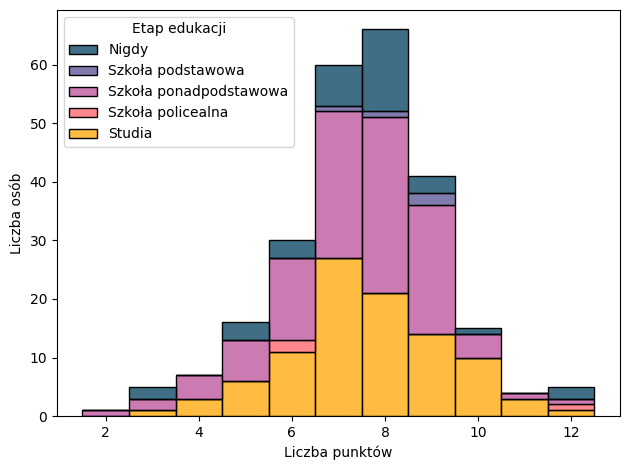

In [55]:
order = ["Nigdy", "Szkoła podstawowa", "Szkoła ponadpodstawowa", "Szkoła policealna", "Studia"]

ax = sns.histplot(data=df, x="wynik", discrete=True, hue='Etap edukacji', palette=["#003f5c", "#575092", "#bb4e99", "#ff5f68", "#ffa600"], multiple="stack", hue_order=order)

plt.xlabel("Liczba punktów")
plt.ylabel("Liczba osób")

plt.tight_layout()
plt.savefig("test/wynik_sta.svg", dpi=300)

In [56]:
counts = df.groupby(["Etap edukacji", "wynik"]).size()
print(counts)

Etap edukacji           wynik
Nigdy                   3         2
                        5         3
                        6         3
                        7         7
                        8        14
                        9         3
                        10        1
                        12        2
Studia                  3         1
                        4         3
                        5         6
                        6        11
                        7        27
                        8        21
                        9        14
                        10       10
                        11        3
                        12        1
Szkoła podstawowa       7         1
                        8         1
                        9         2
Szkoła policealna       6         2
                        12        1
Szkoła ponadpodstawowa  2         1
                        3         2
                        4         4
                        5         

In [57]:
srednie = df.groupby("Etap edukacji")["wynik"].mean()
srednie

Etap edukacji
Nigdy                     7.457143
Studia                    7.618557
Szkoła podstawowa         8.250000
Szkoła policealna         8.000000
Szkoła ponadpodstawowa    7.378378
Name: wynik, dtype: float64

In [58]:
df["Etap edukacji"].value_counts()

Etap edukacji
Szkoła ponadpodstawowa    111
Studia                     97
Nigdy                      35
Szkoła podstawowa           4
Szkoła policealna           3
Name: count, dtype: int64

In [59]:
df["Matematyka rozszerzona"] = df["Matematyka rozszerzona"].map({
    "Nie": "Nie",
    "Tak": "Tak"
})

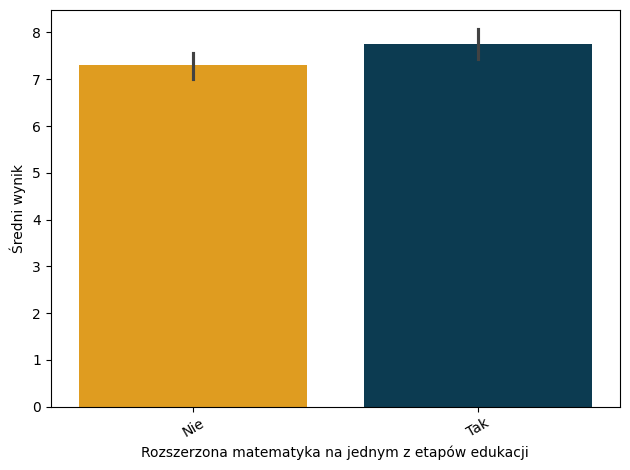

In [60]:
sns.barplot(data=df, x="Matematyka rozszerzona", y="wynik", errorbar=('ci'), hue='Matematyka rozszerzona', palette=["#ffa600", "#003f5c"])
plt.legend().remove() 
plt.ylabel("Średni wynik")
plt.xlabel("Rozszerzona matematyka na jednym z etapów edukacji")
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig("test/sredni_wynik_statystyka_studia.svg", dpi=300)

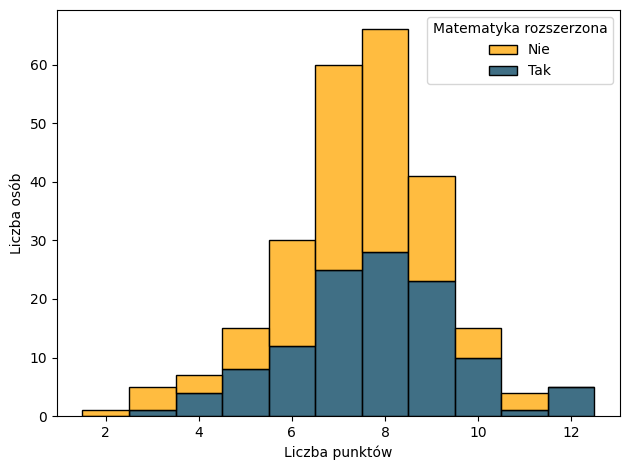

In [61]:
ax = sns.histplot(data=df, x="wynik", discrete=True, hue='Matematyka rozszerzona', palette=["#ffa600", "#003f5c"], multiple="stack")

plt.xlabel("Liczba punktów")
plt.ylabel("Liczba osób")

plt.tight_layout()
plt.savefig("test/wynik_mat.svg", dpi=300)

In [62]:
srednie = df.groupby("Matematyka rozszerzona")["wynik"].mean()
srednie

Matematyka rozszerzona
Nie    7.295455
Tak    7.760684
Name: wynik, dtype: float64

In [63]:
counts = df.groupby(["Matematyka rozszerzona", "wynik"]).size()
print(counts)

Matematyka rozszerzona  wynik
Nie                     2         1
                        3         4
                        4         3
                        5         7
                        6        18
                        7        35
                        8        38
                        9        18
                        10        5
                        11        3
Tak                     3         1
                        4         4
                        5         8
                        6        12
                        7        25
                        8        28
                        9        23
                        10       10
                        11        1
                        12        5
dtype: int64


In [64]:
df["Matematyka rozszerzona"].value_counts()

Matematyka rozszerzona
Nie    132
Tak    117
Name: count, dtype: int64

In [65]:
df["Odpowiedź do zadania 8"] = df["Odpowiedź do zadania 8"].map({
    "aa": "A",
    "a": "A",
    "A. Test rzadko daje wyniki fałszywie dodatnie": "A",
    "B. Test dobrze wykrywa osoby zdrowe": "B",
    "C. Test rzadko pomija pacjentów z niestabilnością": "C",
    "D. Test ma wysoką dokładność ogólną": "D",
    "X": "Brak"
})

In [66]:
df["testy_diag"] = df["testy_diag"].map({
    "Tak. tak": "Tak, tak",
    "Tak. nie": "Tak, nie",
    "Nie": "Nie",
    "X": "Brak"
})

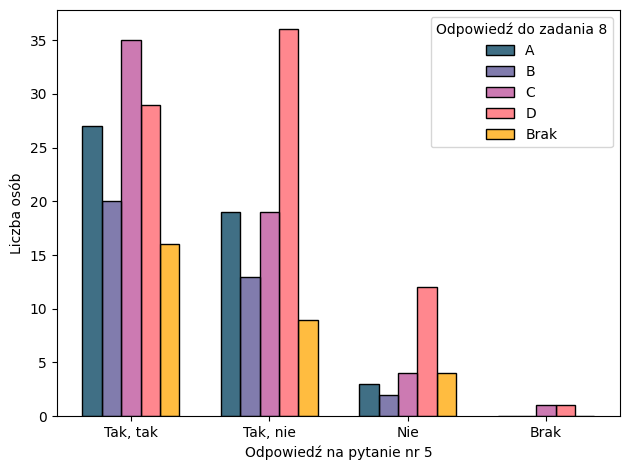

In [34]:
order = ["A", "B", "C", "D", "Brak"]

ax = sns.histplot(data=df, x="testy_diag", discrete=True, hue='Odpowiedź do zadania 8', palette=["#003f5c", "#575092", "#bb4e99", "#ff5f68", "#ffa600"], multiple="dodge", shrink=0.7, hue_order=order)

plt.xlabel('Odpowiedź na pytanie nr 5')
plt.ylabel("Liczba osób")

plt.tight_layout()
plt.savefig("test/wynik_czu.svg", dpi=300)

In [67]:
correct_answer = "C"

df["kategoria"] = df["Odpowiedź do zadania 8"].apply(
    lambda x: "Brak odpowiedzi" if pd.isna(x) or x == "Brak"
    else "Poprawna" if x == correct_answer
    else "Błędna"
)

palette = {
    "Poprawna": "#003f5c",
    "Błędna": "#ffa600",
    "Brak odpowiedzi": "#bb4e99"
}

groups = df["testy_diag"].dropna().unique()
n = len(groups)

cols = 2
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
axes = axes.flatten()

handles = None

for i, g in enumerate(groups):
    ax = axes[i]
    sub = df[df["testy_diag"] == g]

    counts = (
        sub["kategoria"]
        .value_counts()
        .reindex(palette.keys(), fill_value=0)
    )

    wedges, texts, autotexts = ax.pie(
        counts,
        labels=None,  
        autopct=lambda p: f"{p:.1f}%" if p > 0 else "",
        startangle=90,
        colors=[palette[k] for k in counts.index]
    )

    ax.set_title(f"Odpowiedź na pytanie nr 5 - {g}")

    if handles is None:
        handles = wedges

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.legend(
    handles,
    palette.keys(),
    loc="lower center",
    ncol=3
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("test/wszystkie_pie.svg", dpi=300)
plt.close()

In [68]:
df["Odpowiedź do zadania 9"] = df["Odpowiedź do zadania 9"].map({
    "A. Test często wykrywa chorobę u osób zdrowych": "A",
    "B. Test rzadko daje wyniki fałszywie dodatnie": "B",
    "C. Test rzadko daje wyniki fałszywie ujemne": "C",
    "D. Test jest najlepszy jako badanie przesiewowe": "D",
    "X": "Brak"
})

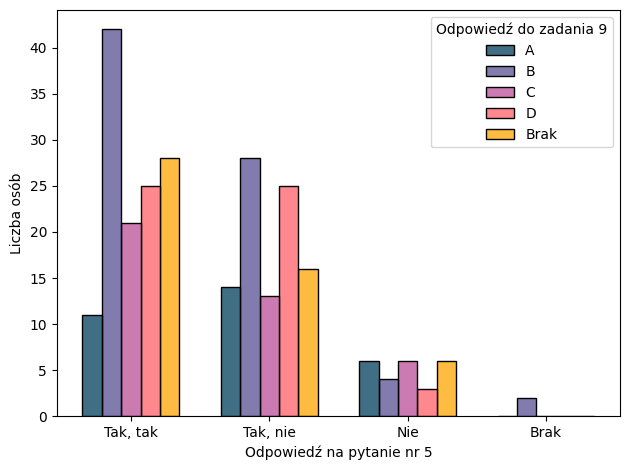

In [70]:
order = ["A", "B", "C", "D", "Brak"]

ax = sns.histplot(data=df, x="testy_diag", discrete=True, hue='Odpowiedź do zadania 9', hue_order=order, palette=["#003f5c", "#575092", "#bb4e99", "#ff5f68", "#ffa600"], multiple="dodge", shrink=0.7)

plt.xlabel("Odpowiedź na pytanie nr 5")
plt.ylabel("Liczba osób")

plt.tight_layout()
plt.savefig("test/wynik_swo.svg", dpi=300)

In [71]:
correct_answer = "B"

df["kategoria"] = df["Odpowiedź do zadania 9"].apply(
    lambda x: "Brak odpowiedzi" if pd.isna(x) or x == "Brak"
    else "Poprawna" if x == correct_answer
    else "Błędna"
)

palette = {
    "Poprawna": "#003f5c",
    "Błędna": "#ffa600",
    "Brak odpowiedzi": "#bb4e99"
}

groups = df["testy_diag"].dropna().unique()
n = len(groups)

cols = 2
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
axes = axes.flatten()

handles = None

for i, g in enumerate(groups):
    ax = axes[i]
    sub = df[df["testy_diag"] == g]

    counts = (
        sub["kategoria"]
        .value_counts()
        .reindex(palette.keys(), fill_value=0)
    )

    wedges, texts, autotexts = ax.pie(
        counts,
        labels=None,  
        autopct=lambda p: f"{p:.1f}%" if p > 0 else "",
        startangle=90,
        colors=[palette[k] for k in counts.index]
    )

    ax.set_title(f"Odpowiedź na pytanie nr 5 - {g}")

    if handles is None:
        handles = wedges

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.legend(
    handles,
    palette.keys(),
    loc="lower center",
    ncol=3
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("test/wszystkie_pie.svg", dpi=300)
plt.close()

In [72]:
df["artykuly_naukowe"] = df["artykuly_naukowe"].map({
    "Tak. tak": "Tak, tak",
    "Tak. nie": "Tak, nie",
    "Nie": "Nie",
    "X": "Brak"
})

In [73]:
df_clean = df[["artykuly_naukowe", 'Odpowiedź do zadania 10']].dropna()

df_clean["Odpowiedzi do zadania 10"] = df_clean['Odpowiedź do zadania 10'].str.findall(r"[A-DX]")
df_exploded = df_clean.explode("Odpowiedzi do zadania 10")

In [74]:
df_exploded["Odpowiedzi do zadania 10"] = df_exploded["Odpowiedzi do zadania 10"].map({
    "A": "A",
    "B": "B",
    "C": "C",
    "D": "D",
    "X": "Brak"
})

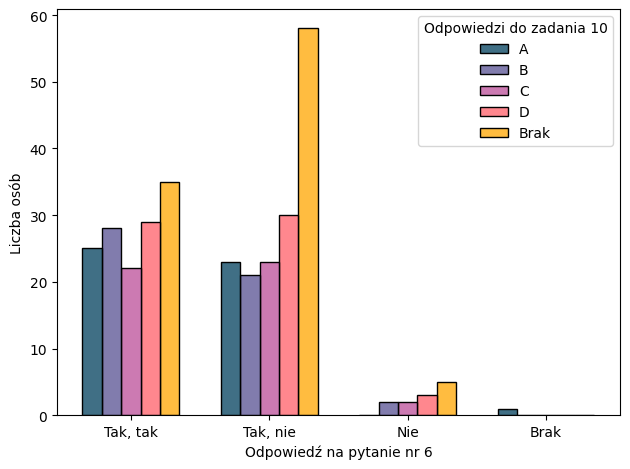

In [75]:
order = ["A", "B", "C", "D", "Brak"]

ax = sns.histplot(data=df_exploded, x="artykuly_naukowe", discrete=True, hue='Odpowiedzi do zadania 10', palette=["#003f5c", "#575092", "#bb4e99", "#ff5f68", "#ffa600"], multiple="dodge", shrink=0.7, hue_order=order)

plt.xlabel('Odpowiedź na pytanie nr 6')
plt.ylabel("Liczba osób")

plt.tight_layout()
plt.savefig("test/wynik_art.svg", dpi=300)


In [76]:
correct_answer = "A. B. D"

df["kategoria"] = df["Odpowiedź do zadania 10"].apply(
    lambda x: "Brak odpowiedzi" if pd.isna(x) or x == "X"
    else "Poprawna" if x == correct_answer
    else "Błędna"
)

palette = {
    "Poprawna": "#003f5c",
    "Błędna": "#ffa600",
    "Brak odpowiedzi": "#bb4e99"
}

groups = df["artykuly_naukowe"].dropna().unique()
n = len(groups)

cols = 2
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
axes = axes.flatten()

handles = None

for i, g in enumerate(groups):
    ax = axes[i]
    sub = df[df["artykuly_naukowe"] == g]

    counts = (
        sub["kategoria"]
        .value_counts()
        .reindex(palette.keys(), fill_value=0)
    )

    wedges, texts, autotexts = ax.pie(
        counts,
        labels=None,  
        autopct=lambda p: f"{p:.1f}%" if p > 0 else "",
        startangle=90,
        colors=[palette[k] for k in counts.index]
    )

    ax.set_title(f"Odpowiedź na pytanie nr 6 - {g}")

    if handles is None:
        handles = wedges

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.legend(
    handles,
    palette.keys(),
    loc="lower center",
    ncol=3
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("test/wszystkie_pie.svg", dpi=300)
plt.close()

In [82]:
cols = df.columns[0:20]  # dostosuj zakres!

for col in cols:
    print(f"\n=== {col} ===")
    print(df[col].value_counts())


=== ankieta ===
ankieta
1.0     1
2.0     1
3.0     1
4.0     1
5.0     1
6.0     1
7.0     1
8.0     1
9.0     1
10.0    1
11.0    1
12.0    1
Name: count, dtype: int64

=== Płeć ===
Płeć
Kobieta      176
Mężczyzna     74
Name: count, dtype: int64

=== Matematyka rozszerzona ===
Matematyka rozszerzona
Nie    132
Tak    117
Name: count, dtype: int64

=== Etap edukacji ===
Etap edukacji
Szkoła ponadpodstawowa    111
Studia                     97
Nigdy                      35
Szkoła podstawowa           4
Szkoła policealna           3
Name: count, dtype: int64

=== statystyka_studia ===
statystyka_studia
Tak    184
Nie     63
X        3
Name: count, dtype: int64

=== testy_diag ===
testy_diag
Tak, tak    127
Tak, nie     96
Nie          25
Brak          2
Name: count, dtype: int64

=== artykuly_naukowe ===
artykuly_naukowe
Tak, nie    134
Tak, tak    105
Nie          10
Brak          1
Name: count, dtype: int64

=== srednia_kolano ===
srednia_kolano
130.0    213
125.0     23
135.0     1